In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from tools import load_data

# Random Forest (RF)

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$\mathbf{X} \rightarrow \mathrm{EIT}$$
$$A \rightarrow \mathrm{Angle}$$
$$T \rightarrow \mathrm{Torque}$$
$$F \rightarrow \mathrm{Force}$$

In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
# Adjustment place
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [1, 2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

In [5]:
p1s = indices_with_tolerance(A, 25, tol=1)  # Adjustment place
p2s = indices_with_tolerance(A, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(A, 75, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"]  # Adjustment place
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


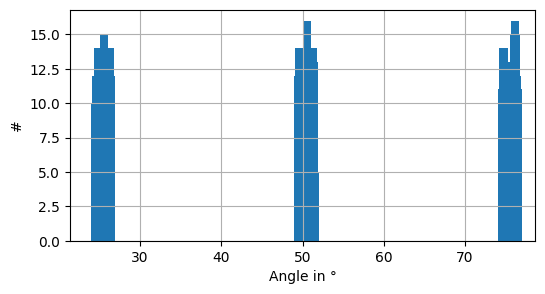

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
y = A[targets]  # A -> Angle # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [8]:
params_path = "params/TrainValid_A_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Beste CV-Accuracy: 0.9805884378196105
beste parameter: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [9]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.9762
Fold 2 Balanced Accuracy: 0.9809
Fold 3 Balanced Accuracy: 0.9873
Fold 4 Balanced Accuracy: 0.9936
Fold 5 Balanced Accuracy: 0.9633

Mean Balanced Accuracy: 0.9802612592086277
Std Balanced Accuracy: 0.010309872706206388

accuracy_score: 0.98026734563972
balanced_accuracy_score: 0.98026592396548
r2_score: 0.9589498744319968



Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      1047
         1.0       0.97      0.97      0.97      1047
         2.0       0.97      0.98      0.98      1048

    accuracy                           0.98      3142
   macro avg       0.98      0.98      0.98      3142
weighted avg       0.98      0.98      0.98      3142



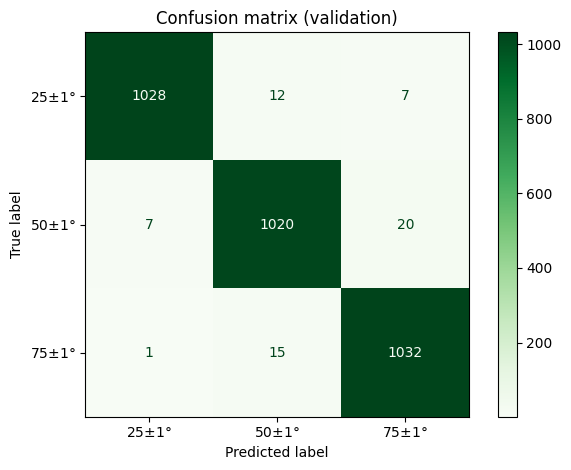

In [10]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_A_RF.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [11]:
params_path = "params/TrainTest_A_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV-Accuracy: 0.374927808673699
Best parameter: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [12]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3444
Fold 2 Accuracy: 0.3465
Fold 3 Accuracy: 0.3658
Fold 4 Accuracy: 0.4028
Fold 5 Accuracy: 0.2981

Mean Accuracy: 0.35149060979596164
Std Accuracy: 0.03394673209464053

accuracy_score 0.3539147040101846
balanced_accuracy_score 0.35390343426389714



Classification Report:
              precision    recall  f1-score   support

         0.0       0.35      0.47      0.40      1047
         1.0       0.33      0.20      0.25      1047
         2.0       0.37      0.39      0.38      1048

    accuracy                           0.35      3142
   macro avg       0.35      0.35      0.34      3142
weighted avg       0.35      0.35      0.34      3142



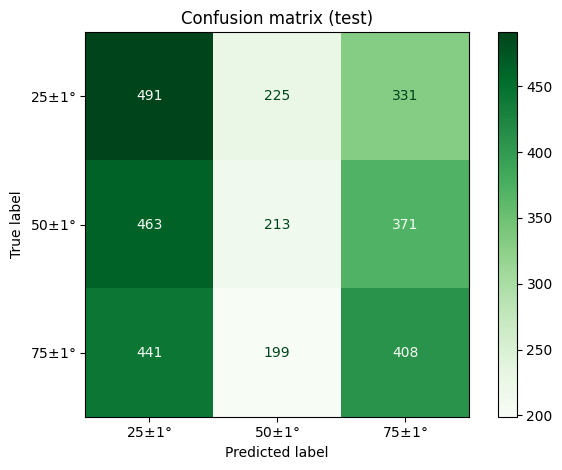

In [13]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_A_RF.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [14]:
p1s = indices_with_tolerance(T, 30, tol=1)  # Adjustment place
p2s = indices_with_tolerance(T, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(T, 70, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20Nm", r"125$\pm$20Nm", r"200$\pm$20Nm"]  # Adjustment place
np.random.shuffle(targets)

Found 2,523 for position 30 and a tolerance of 1.
Found 1,953 for position 50 and a tolerance of 1.
Found 1,249 for position 70 and a tolerance of 1.


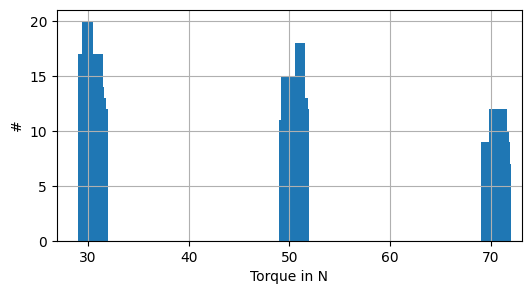

In [15]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in N")  # Adjustment place
plt.show()

In [16]:
y = T[targets]  # T -> Torque # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [17]:
params_path = "params/TrainValid_T_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Beste CV-Accuracy: 0.788995633187773
beste parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [18]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.7842
Fold 2 Balanced Accuracy: 0.7816
Fold 3 Balanced Accuracy: 0.7756
Fold 4 Balanced Accuracy: 0.7861
Fold 5 Balanced Accuracy: 0.7930

Mean Balanced Accuracy: 0.7840921062877613
Std Balanced Accuracy: 0.005699643873490422

accuracy_score: 0.7841048034934498
balanced_accuracy_score: 0.7840953642296832
r2_score: 0.6431752522065846



Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82      1908
         1.0       0.69      0.69      0.69      1908
         2.0       0.85      0.84      0.84      1909

    accuracy                           0.78      5725
   macro avg       0.78      0.78      0.78      5725
weighted avg       0.78      0.78      0.78      5725



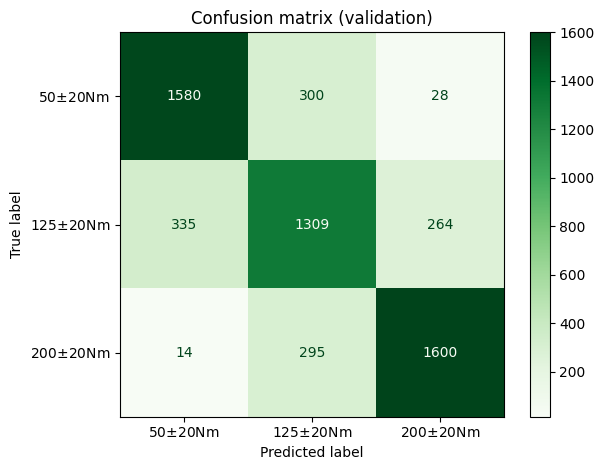

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_T_RF.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [20]:
params_path = "params/TrainTest_T_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV-Accuracy: 0.38915988408441476
Best parameter: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [21]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3717
Fold 2 Accuracy: 0.3185
Fold 3 Accuracy: 0.3117
Fold 4 Accuracy: 0.3929
Fold 5 Accuracy: 0.3005

Mean Accuracy: 0.3390473190973065
Std Accuracy: 0.036370401059581926

accuracy_score 0.34934497816593885
balanced_accuracy_score 0.3493806600021451



Classification Report:
              precision    recall  f1-score   support

         0.0       0.40      0.28      0.33      1908
         1.0       0.34      0.62      0.44      1908
         2.0       0.31      0.15      0.20      1909

    accuracy                           0.35      5725
   macro avg       0.35      0.35      0.32      5725
weighted avg       0.35      0.35      0.32      5725



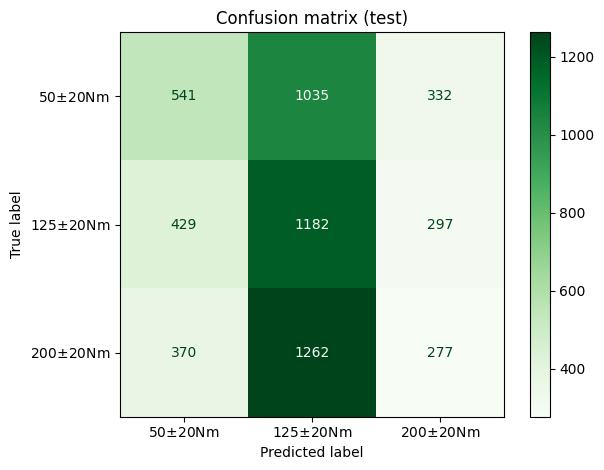

In [22]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_T_RF.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [23]:
p1s = indices_with_tolerance(F, 50, tol=2)  # Adjustment place
p2s = indices_with_tolerance(F, 125, tol=2)  # Adjustment place
p3s = indices_with_tolerance(F, 200, tol=2)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$N", r"100$\pm$N", r"175$\pm$N"]  # Adjustment place
np.random.shuffle(targets)

Found 1,208 for position 50 and a tolerance of 2.
Found 1,545 for position 125 and a tolerance of 2.
Found 901 for position 200 and a tolerance of 2.


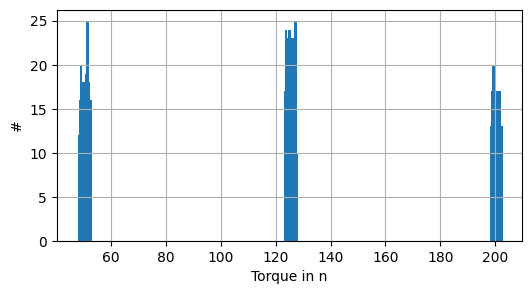

In [24]:
plt.figure(figsize=(6, 3))
plt.hist(F[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in n")
plt.show()

In [25]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [26]:
params_path = "params/TrainValid_F_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Beste CV-Accuracy: 0.8382598429623522
beste parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [27]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.8482
Fold 2 Balanced Accuracy: 0.8263
Fold 3 Balanced Accuracy: 0.8345
Fold 4 Balanced Accuracy: 0.8235
Fold 5 Balanced Accuracy: 0.8192

Mean Balanced Accuracy: 0.8303211225797748
Std Balanced Accuracy: 0.0102305873992723

accuracy_score: 0.8303229337712096
balanced_accuracy_score: 0.8303229337712096
r2_score: 0.65311986863711



Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.89      1218
         1.0       0.76      0.81      0.78      1218
         2.0       0.84      0.81      0.82      1218

    accuracy                           0.83      3654
   macro avg       0.83      0.83      0.83      3654
weighted avg       0.83      0.83      0.83      3654



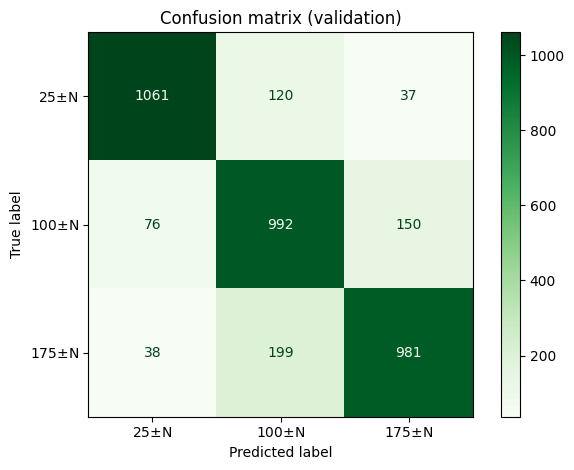

In [28]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_F_RF.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [29]:
params_path = "params/TrainTest_F_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV-Accuracy: 0.4177788945033517
Best parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 10}


In [30]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3370
Fold 2 Accuracy: 0.2989
Fold 3 Accuracy: 0.3444
Fold 4 Accuracy: 0.2837
Fold 5 Accuracy: 0.4041

Mean Accuracy: 0.33359899029365153
Std Accuracy: 0.04194449395769901

accuracy_score 0.32950191570881227
balanced_accuracy_score 0.3295019157088122



Classification Report:
              precision    recall  f1-score   support

         0.0       0.32      0.68      0.44      1218
         1.0       0.20      0.04      0.06      1218
         2.0       0.38      0.27      0.32      1218

    accuracy                           0.33      3654
   macro avg       0.30      0.33      0.27      3654
weighted avg       0.30      0.33      0.27      3654



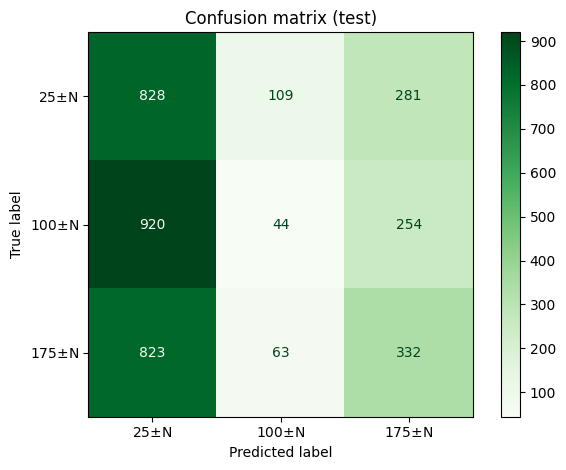

In [31]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_F_RF.pdf")  # Adjustment place
plt.show()

___